In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
import timm
import time
import matplotlib.pyplot as plt

# ----------------------------
# GPU Info
# ----------------------------

num_gpus = torch.cuda.device_count()
print(f"GPUs available: {num_gpus}")
if num_gpus > 0:
    for i in range(num_gpus):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

# ----------------------------
# Data Transforms
# ----------------------------
train_tfms = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_tfms = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ----------------------------
# Datasets 
# ----------------------------
train_ds = datasets.ImageFolder("/kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/train", transform=train_tfms)
val_ds   = datasets.ImageFolder("/kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/valid", transform=val_tfms)
test_ds  = datasets.ImageFolder("/kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/test", transform=val_tfms)

print(f"Train samples: {len(train_ds)}")
print(f"Validation samples: {len(val_ds)}")
print(f"Test samples: {len(test_ds)}")

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=64, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=64, num_workers=4, pin_memory=True)

# ----------------------------
# Model Setup
# ----------------------------

model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = nn.DataParallel(model)   # run on multiple GPUs
model.to(device)

criterion = nn.CrossEntropyLoss()
scaler = torch.amp.GradScaler("cuda")

train_accs, val_accs = [] , []

# ----------------------------
# Training Function
# ----------------------------

def train_phase(model, optimizer, scheduler, epochs, phase_name):
    global train_accs, val_accs
    for epoch in range(epochs):
        epoch_start = time.time()
        # Training
        model.train()
        correct, total = 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            optimizer.zero_grad()
            with torch.amp.autocast(device_type = "cuda"):
                outputs = model(imgs)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        train_acc = correct / total

        # Validation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
                with torch.amp.autocast(device_type = "cuda"):
                    outputs = model(imgs)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        val_acc = correct / total

        scheduler.step()
        epoch_time = time.time() - epoch_start
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        print(f"{phase_name} Epoch {epoch+1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}, Time={epoch_time/60:.2f} min")

# ----------------------------
# Phase 1: Train head only
# ----------------------------
for param in model.parameters():
    param.requires_grad = False
for param in model.module.head.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(model.module.head.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5)
train_phase(model, optimizer, scheduler, epochs=5, phase_name="Phase 1")

# ----------------------------
# Phase 2: Unfreeze last 2 transformer blocks
# ----------------------------
for name, param in model.module.named_parameters():
    if "blocks.10" in name or "blocks.11" in name:
        param.requires_grad = True

optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
train_phase(model, optimizer, scheduler, epochs=10, phase_name="Phase 2")

# ----------------------------
# Phase 3: Full fine-tune
# ----------------------------
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(model.parameters(), lr=5e-6, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)
train_phase(model, optimizer, scheduler, epochs=15, phase_name="Phase 3")

# ----------------------------
# Final Test Evaluation
# ----------------------------
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        with torch.amp.autocast(device_type = "cuda"):
            outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Precision, Recall, F1
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("Classification Report:\n", classification_report(y_true, y_pred, target_names=["Fake","Real"]))
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")

# ----------------------------
# Plot Training vs Validation Accuracy
# ----------------------------

plt.figure(figsize=(10,6))
plt.plot(range(1, len(train_accs)+1), train_accs, label="Train Accuracy")
plt.plot(range(1, len(val_accs)+1), val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


GPUs available: 2
GPU 0: Tesla T4
GPU 1: Tesla T4
Train samples: 100000
Validation samples: 20000
Test samples: 20000


Phase 1 Epoch 1: Train Acc=0.8332, Val Acc=0.8775, Time=5.56 min
Phase 1 Epoch 2: Train Acc=0.8613, Val Acc=0.8817, Time=4.42 min
Phase 1 Epoch 3: Train Acc=0.8655, Val Acc=0.8885, Time=4.51 min
Phase 1 Epoch 4: Train Acc=0.8709, Val Acc=0.8791, Time=4.58 min
Phase 1 Epoch 5: Train Acc=0.8735, Val Acc=0.8881, Time=4.60 min
Phase 2 Epoch 1: Train Acc=0.9174, Val Acc=0.9625, Time=5.60 min
Phase 2 Epoch 2: Train Acc=0.9590, Val Acc=0.9706, Time=5.61 min
Phase 2 Epoch 3: Train Acc=0.9752, Val Acc=0.9759, Time=5.62 min
Phase 2 Epoch 4: Train Acc=0.9823, Val Acc=0.9824, Time=5.63 min
Phase 2 Epoch 5: Train Acc=0.9877, Val Acc=0.9845, Time=5.61 min
Phase 2 Epoch 6: Train Acc=0.9913, Val Acc=0.9858, Time=5.61 min
Phase 2 Epoch 7: Train Acc=0.9937, Val Acc=0.9867, Time=5.59 min
Phase 2 Epoch 8: Train Acc=0.9948, Val Acc=0.9881, Time=5.51 min
Phase 2 Epoch 9: Train Acc=0.9962, Val Acc=0.9882, Time=5.53 min
Phase 2 Epoch 10: Train Acc=0.9966, Val Acc=0.9887, Time=5.57 min
Phase 3 Epoch 1: Train A

NameError: name 'z' is not defined

In [3]:
torch.save(model.module.state_dict(), "vit_deepfake_model.pth")
print("Model saved successfully!")

Model saved successfully!


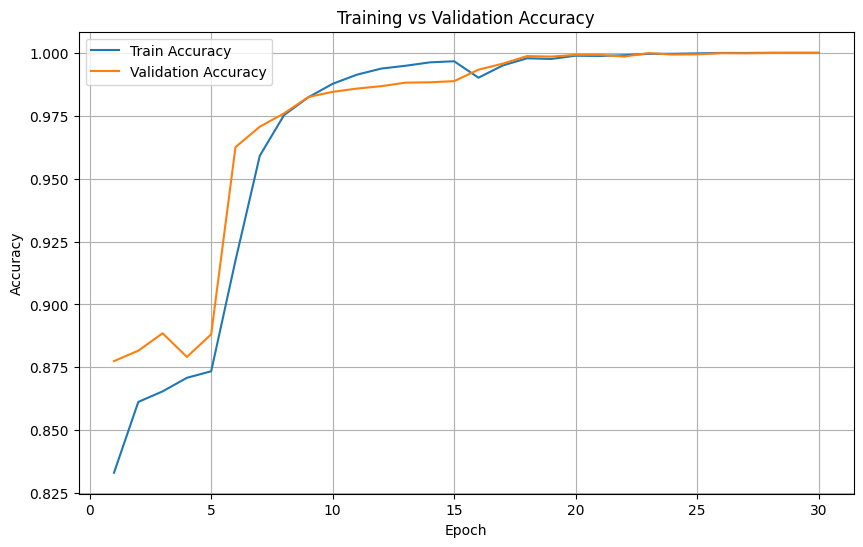

In [4]:
# ----------------------------
# Plot Training vs Validation Accuracy
# ----------------------------
plt.figure(figsize=(10,6))
plt.plot(range(1, len(train_accs)+1), train_accs, label="Train Accuracy")
plt.plot(range(1, len(val_accs)+1), val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

# Save the plot
plt.savefig("/kaggle/working/training_validation_accuracy.png",
            dpi=300,
            bbox_inches='tight')